# Fine-tuning — EQTransformer

Fine-tunes EQTransformer using the shared local dataset and saves the trained weights and loss history. Architecture-specific settings are defined below.


## Key settings

EQTransformer uses 60 s windows with peak normalization. Separate detection, P, and S outputs are trained with binary cross-entropy; dev loss controls early stopping. A baseline snapshot is retained for comparison.

## 1. Environment + shared utilities

In [1]:
import sys
sys.path.insert(0, r"M:\Github\TFM_SeismicPhasePicker_ColombianAndesRegion\src\training")
import training_utils as tu
import torch
import torch.nn.functional as F
import numpy as np
import seisbench.models as sbm
import seisbench.generate as sbg
from torch.utils.data import DataLoader
tu.banner()

seisbench 0.12.3 | torch 2.5.1+cu121 | device: cuda


## 2. Configuration

In [2]:
ARCH       = "EQTransformer"
STATIONS   = None
PRETRAINED = "instance"
EPOCHS     = 100
BATCH_SIZE = 32           # EQT is heavier than PhaseNet
LR         = 1e-4
SIGMA      = 20
SEED       = 42
PATIENCE   = 6
MIN_DELTA  = 1e-4
IN_SAMPLES = 6000

torch.manual_seed(SEED); np.random.seed(SEED)
FT_CKPT   = tu.MODELS_DIR / f"{ARCH.lower()}_ft.pt"
BASE_CKPT = tu.MODELS_DIR / f"{ARCH.lower()}_baseline_{PRETRAINED}.pt"
print("Stations:", "ALL" if not STATIONS else STATIONS, "| checkpoint:", FT_CKPT.name)

Stations: ALL | checkpoint: eqtransformer_ft.pt


## 3. Dataset (train / dev)

In [3]:
data = tu.load_dataset(STATIONS)
train, dev, test = data.train_dev_test()
print()
tu.split_summary(train, "train"); tu.split_summary(dev, "dev")
print(f"  (test reserved for evaluate: {len(test)})")

No filter (all stations): 106580 traces
stations: ['BRJC', 'CBOC', 'CHI', 'DBB', 'GUY2C', 'JAMC', 'MAL', 'NOR', 'ORTC', 'PAL', 'PIZC', 'PRA', 'PTB', 'PTGC', 'QUBC', 'RUS', 'SPBC', 'TAM', 'URE', 'URMC', 'YOT', 'ZAR']

  train: 74600  {'earthquake': 37300, 'noise': 37300}
  dev  : 16414  {'earthquake': 8207, 'noise': 8207}
  (test reserved for evaluate: 15566)


## 4. Base model + baseline snapshot

In [4]:
model = sbm.EQTransformer.from_pretrained(PRETRAINED).to(tu.DEVICE)
print("labels:", model.labels, "| in_samples:", model.in_samples, "| norm:", model.norm)
torch.save(model.state_dict(), BASE_CKPT)
print("baseline saved:", BASE_CKPT.name)

c:\Users\moise\miniconda3\envs\tesismaster\Lib\site-packages\seisbench\models\base.py:952: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(f"{path_p

labels: ['Detection', 'P', 'S'] | in_samples: 6000 | norm: peak
baseline saved: eqtransformer_baseline_instance.pt


## 5. Training generators (EQTransformer-specific)

In [5]:
P_COL, S_COL = "trace_p_arrival_sample", "trace_s_arrival_sample"

def make_train_gen(subset):
    gen = sbg.GenericGenerator(subset)
    gen.add_augmentations([
        sbg.WindowAroundSample(list(tu.PHASE_DICT.keys()), samples_before=6000,
                               windowlen=12000, selection="random", strategy="variable"),
        sbg.RandomWindow(windowlen=IN_SAMPLES, strategy="pad"),
        sbg.Normalize(demean_axis=-1, amp_norm_axis=-1, amp_norm_type="peak"),
        sbg.ChangeDtype(np.float32),
        # P and S as Gaussians (2 channels), under key "y"
        sbg.ProbabilisticLabeller(label_columns=tu.PHASE_DICT, sigma=SIGMA, dim=0,
                                  model_labels=["P", "S"]),
        # detection as a P->S box, under key "detections"
        sbg.DetectionLabeller(p_phases=[P_COL], s_phases=[S_COL], factor=1.4,
                              key=("X", "detections")),
    ])
    return gen

train_loader = DataLoader(make_train_gen(train), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, drop_last=True)
dev_loader   = DataLoader(make_train_gen(dev), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Shape diagnostic (to validate the recipe on the first run)
_b = next(iter(train_loader))
print("keys:", list(_b.keys()))
print("X:", tuple(_b["X"].shape), " y:", tuple(_b["y"].shape),
      " detections:", tuple(_b["detections"].shape))
print("batches -> train:", len(train_loader), " dev:", len(dev_loader))

keys: ['X', 'y', 'detections']
X: (32, 3, 6000)  y: (32, 3, 6000)  detections: (32, 1, 6000)
batches -> train: 2331  dev: 513


## 6. Combined loss (EQTransformer-specific) + fine-tuning

In [6]:
def loss_fn(out, batch):
    det, P, S = out                       # each (B, W), sigmoid in [0,1]
    y = batch["y"].float()                # (B, C, W): channel 0 = P, channel 1 = S
    d = batch["detections"].float()       # (B, 1, W) or (B, W)
    if d.dim() == 3:
        d = d[:, 0]
    det, P, S = det.float(), P.float(), S.float()   # BCE requires matching dtype (float32)
    return (F.binary_cross_entropy(det, d) +
            F.binary_cross_entropy(P, y[:, 0]) +
            F.binary_cross_entropy(S, y[:, 1]))

hist, best, best_ep, reason = tu.fit(model, train_loader, dev_loader, loss_fn,
                                     epochs=EPOCHS, patience=PATIENCE,
                                     min_delta=MIN_DELTA, lr=LR)

epoch 01/100   train=0.1742   dev=0.1584  *best dev*
epoch 02/100   train=0.1579   dev=0.1535  *best dev*
epoch 03/100   train=0.1522   dev=0.1503  *best dev*
epoch 04/100   train=0.1489   dev=0.1483  *best dev*
epoch 05/100   train=0.1472   dev=0.1501  (no improvement 1/6)
epoch 06/100   train=0.1443   dev=0.1440  *best dev*
epoch 07/100   train=0.1431   dev=0.1447  (no improvement 1/6)
epoch 08/100   train=0.1420   dev=0.1435  *best dev*
epoch 09/100   train=0.1411   dev=0.1425  *best dev*
epoch 10/100   train=0.1395   dev=0.1434  (no improvement 1/6)
epoch 11/100   train=0.1395   dev=0.1422  *best dev*
epoch 12/100   train=0.1383   dev=0.1443  (no improvement 1/6)
epoch 13/100   train=0.1377   dev=0.1414  *best dev*
epoch 14/100   train=0.1375   dev=0.1405  *best dev*
epoch 15/100   train=0.1360   dev=0.1407  (no improvement 1/6)
epoch 16/100   train=0.1359   dev=0.1427  (no improvement 2/6)
epoch 17/100   train=0.1356   dev=0.1433  (no improvement 3/6)
epoch 18/100   train=0.1341  

### Loss curve

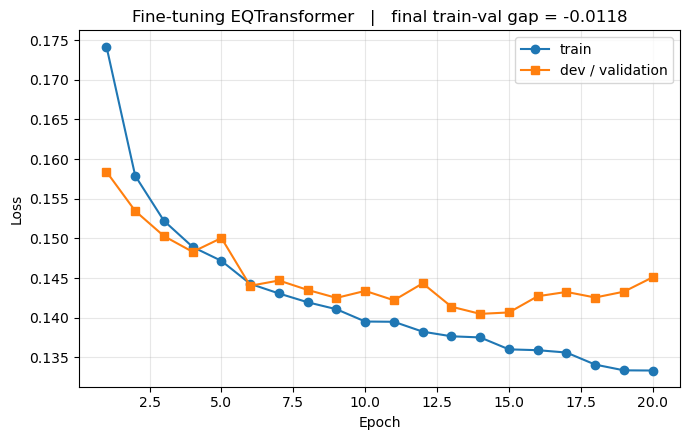

[!] Possible overfitting: dev reached its minimum at epoch 14 and rose 0.0046. Early stopping already restores that epoch.


In [7]:
tu.plot_loss(hist, ARCH)

## 7. Save fine-tuned weights

In [8]:
torch.save(model.state_dict(), FT_CKPT)
print("fine-tuned saved:", FT_CKPT)
print("baseline (for evaluation):", BASE_CKPT)

fine-tuned saved: M:\Github\TFM_SeismicPhasePicker_ColombianAndes\data\processed\models\eqtransformer_ft.pt
baseline (for evaluation): M:\Github\TFM_SeismicPhasePicker_ColombianAndes\data\processed\models\eqtransformer_baseline_instance.pt
